In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import date
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather, InitialConditions

from aquacrop_slovenia import config
from aquacrop_slovenia.prepare_weather import load_station_weather
from aquacrop_slovenia.intial_conditions_defaults import intial_cond_params
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop
from aquacrop_slovenia.parameter_defaults_rakican import rakican_soil_layers, rakican_curve_number, rakican_readily_evaporable_water, rakican_maize_params, optimal_management, deep_groundwater, rakican_soil_layers_old

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
# Set up working directory for outputs
output_dir = config.MODELS_DIR / "testing2"
LOCATION = "rakican"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year. There is no yield observations for 1998 and 2023

In [4]:
#year = 1993
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 10), # TODO temporary
        "planting_date": date(year, 4, 20), # TODO temporary
        "is_seeding_year": True,
    }
#]
for year in range(1993, 2024) if year not in [1998,2017,2023]]

In [5]:
rakican_temperatures, rakican_eto, rakican_rain = load_station_weather(355) # Rakičan uses ARSO meteo station 355 data

In [6]:
historical_co2 = get_co2_for_aquacrop("historical")

In [7]:
rakican_weather = Weather(
    location=LOCATION,
    temperatures=rakican_temperatures,
    eto_values=rakican_eto,
    rainfall_values=rakican_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [8]:
rakican_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=rakican_maize_params
)

In [9]:
rakican_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=rakican_soil_layers_old,
    curve_number=rakican_curve_number,
    readily_evaporable_water=rakican_readily_evaporable_water
)

In [10]:
default_initial_conditions = InitialConditions(
    name="DefaultInitialConditions",
    description="Default initial conditions with AquaCrop calculated defaults",
    params=intial_cond_params
)

In [11]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=rakican_maize,
    soil=rakican_soil,
    management=optimal_management,
    initial_conditions=default_initial_conditions,
    #ground_water=deep_groundwater,
    climate=rakican_weather,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [13]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\models\testing2
Running AquaCrop simulation with project file: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\models\testing2\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\models\testing2\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [14]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,413.9,754.2,1353.7,355.97,0.0,403.5,...,35.7,6.345,7.050,2.15,0.0,0.0,10,10,1993,PROJECT.PRM
1,2,1,1,1994,789.6,737.2,1439.9,357.58,0.0,751.8,...,43.2,9.835,10.927,2.70,0.0,0.0,10,10,1994,PROJECT.PRM
2,3,1,1,1995,820.1,695.1,1250.7,359.53,0.0,776.5,...,42.9,9.122,10.136,2.79,0.0,0.0,10,10,1995,PROJECT.PRM
3,4,1,1,1996,885.7,646.3,1151.8,361.26,0.0,828.0,...,43.2,9.155,10.172,2.84,0.0,0.0,10,10,1996,PROJECT.PRM
4,5,1,1,1997,541.3,710.3,1251.6,362.43,0.0,528.4,...,43.3,9.816,10.907,3.21,0.0,0.0,10,10,1997,PROJECT.PRM
5,6,1,1,1999,614.4,673.6,1414.7,366.96,0.0,600.3,...,43.1,10.238,11.376,2.83,0.0,0.0,10,10,1999,PROJECT.PRM
6,7,1,1,2000,467.3,778.2,1498.1,368.25,0.0,461.4,...,28.4,4.636,5.151,1.65,0.0,0.0,10,10,2000,PROJECT.PRM
7,8,1,1,2001,578.3,726.8,1370.2,369.65,0.0,564.4,...,41.2,8.070,8.966,2.65,0.0,0.0,10,10,2001,PROJECT.PRM
8,9,1,1,2002,573.1,732.0,1416.4,371.87,0.0,567.0,...,43.4,11.278,12.531,2.84,0.0,0.0,10,10,2002,PROJECT.PRM
9,10,1,1,2003,417.1,808.8,1598.4,374.22,0.0,412.0,...,17.6,2.177,2.419,0.87,0.0,0.0,10,10,2003,PROJECT.PRM


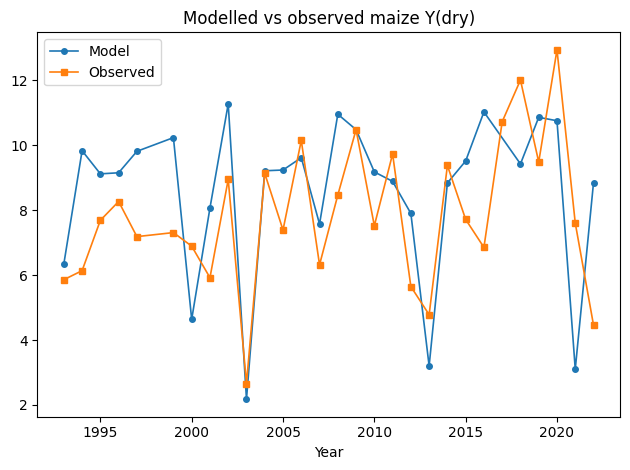

In [15]:
plot_yield_timeseries_comparison(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

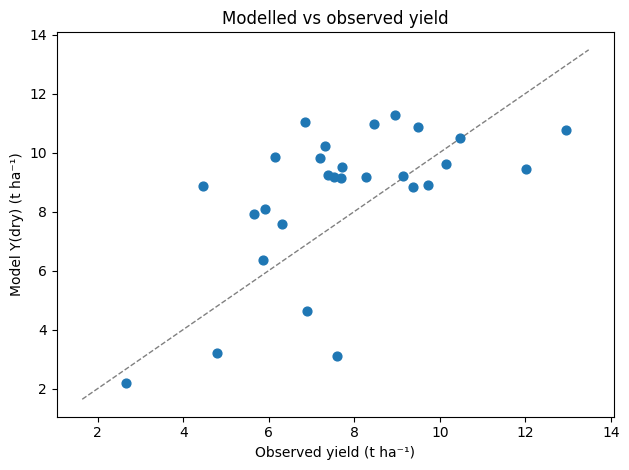

In [16]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"))

In [16]:
print(root_mean_squared_error(results["season"][["Year1", "Y(dry)"]], get_yield_for_comparison(LOCATION, "grain", "A", "N3")))
print(r2_score(results["season"][["Year1", "Y(dry)"]], get_yield_for_comparison(LOCATION, "grain", "A", "N3")))

1.6898256936737588
-3.326128880101245


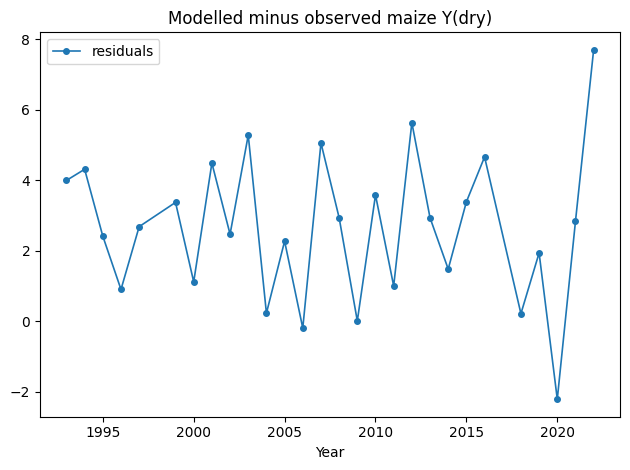

In [17]:
plot_yield_timeseries_residuals(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

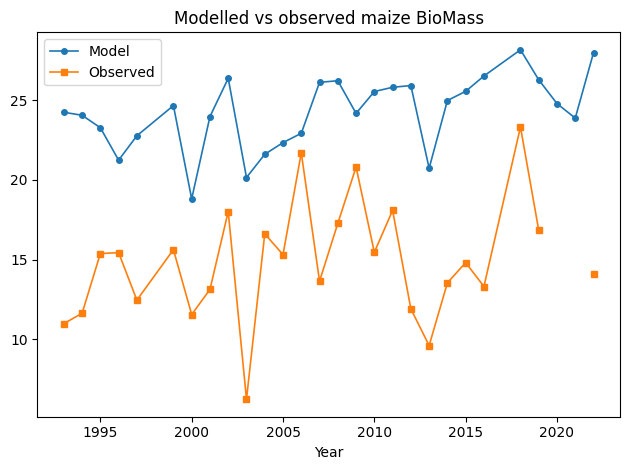

In [18]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass")

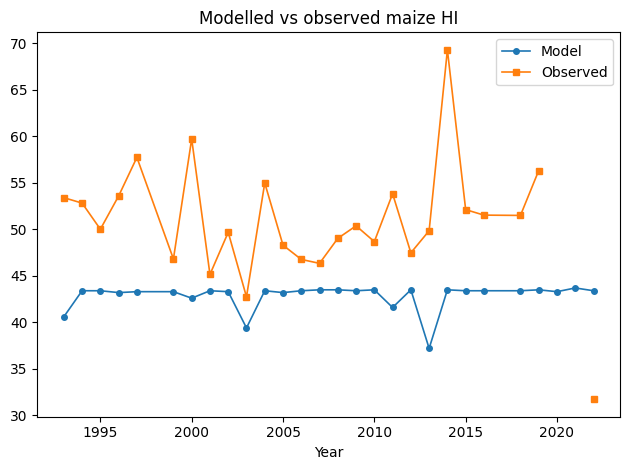

In [19]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "hi", "A", "N3"), "HI")

In [20]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(1.50),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,207.0,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,206.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,205.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,206.8,1.4,0.0,0.0,1.4,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,207.4,0.6,0.0,0.0,0.6,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,6,10,1993,-9,0,193.2,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
279,7,10,1993,-9,0,192.3,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
280,8,10,1993,-9,0,191.5,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
281,9,10,1993,-9,0,190.1,1.0,0.0,0.0,1.0,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

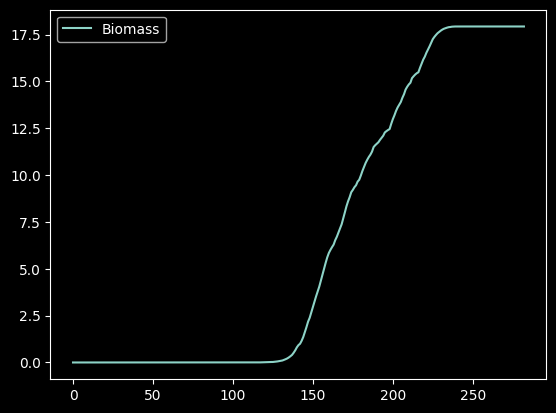

In [21]:
results["day"].plot(y="Biomass")

<Axes: >

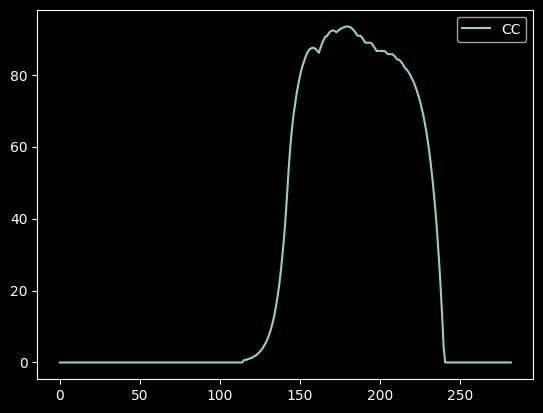

In [22]:
results["day"].plot(y="CC")

<Axes: >

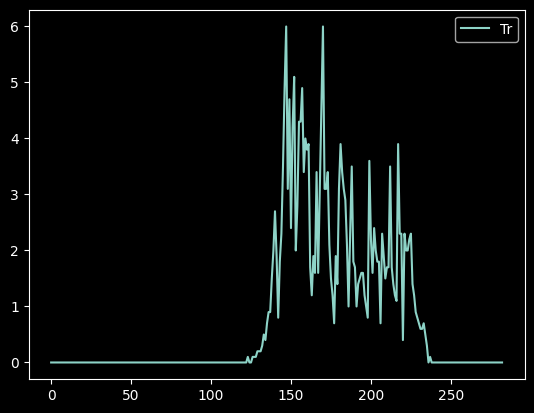

In [23]:
results["day"].plot(y="Tr")

<Axes: >

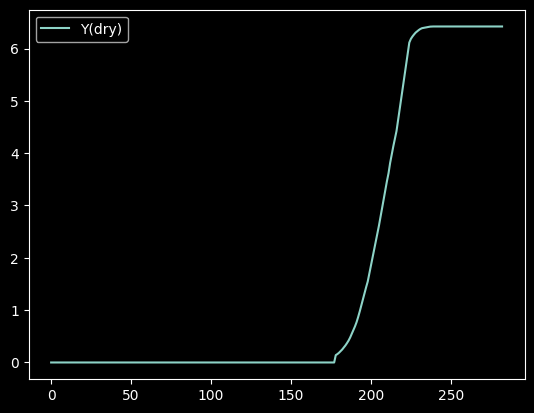

In [24]:
results["day"].plot(y="Y(dry)")